## Title: Part 1
## Author: Laven_240730653
## Date: 2025-11-30

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

## Part 1A
### Aim to simulate random numbers from the target distribution with probability density function:
- Start at an initial value $X_0$.
- At each iteration $i$, propose a new candidate $x^* \sim \mathcal{N}(X_{i-1}, s^2)$ (random walk proposal).
- Compute the log acceptance ratio: $\log r = \log f(x^*) - \log f(X_{i-1})$
- Accept $x^*$ with probability $\min(1, r)$; otherwise stay at $X_{i-1}$.
- Repeat for $N$ iterations to obtain a chain of samples.

In [2]:
# Define the target density: f(x) = 0.5 * exp(-|x|)
def DF(x):
    return 0.5 * np.exp(-np.abs(x))

### Random Walk Metropolis


- `X0`: the initial starting value of the chain  
- `N`: the number of samples (iterations) to generate  
- `s`: the standard deviation of the proposal distribution

In [3]:
np.random.seed(22)

def rand_walk_metro(X0, N, s):
    samples = np.zeros(N)
    samples[0] = X0 

    for i in range(1,N):
        now = samples[i - 1]
        x_star = np.random.normal(loc=now, scale=s)          # Propose the new candidate
        log_ratio = np.log(DF(x_star)) - np.log(DF(now))     # Log acceptance ratio
        log_u = np.log(np.random.uniform())                  # Log of uniform random variable

        if log_u < log_ratio:
            samples[i] = x_star  # Accept
        else:
            samples[i] = now     # Reject: stay at current value

    return samples

### Parameters

In [4]:
X0 = 0
N  = 10001
s  = 1

result = rand_walk_metro(X0, N, s)

print(f"Number of samples: {len(result)}")
print(f"Estimated Sample Mean: {np.mean(result):.6f}")
print(f"Estimated Sample Standard Deviation: {np.std(result, ddof=1):.6f}")

Number of samples: 10001
Estimated Sample Mean: 0.092763
Estimated Sample Standard Deviation: 1.444231


### PLOT

The histogram of the generated samples is overlaid with:
- The **KDE** — a smooth empirical approximation of the sample distribution
- The **True Target Density** $f(x) = \frac{1}{2}e^{-|x|}$ — shown as a dashed curve for comparison

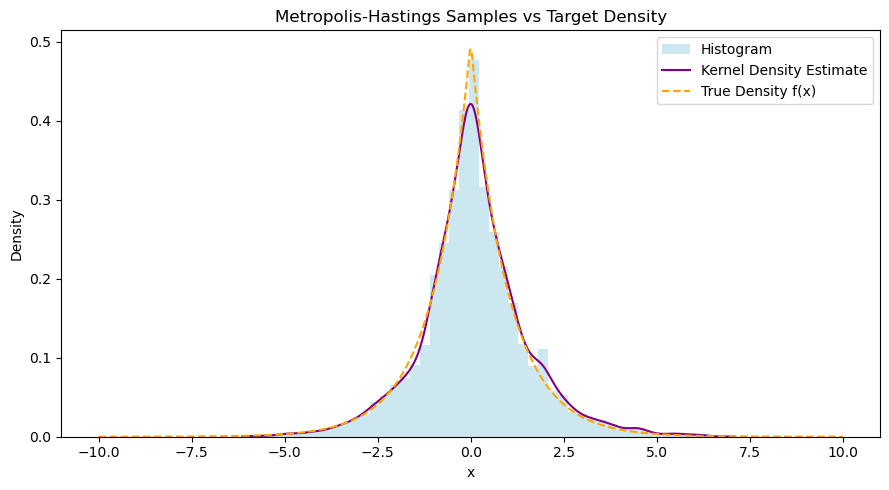

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

# Histogram
ax.hist(result, bins=50, density=True, alpha=0.6, color='lightblue', label='Histogram')

# KDE
kde = gaussian_kde(result)
x_range = np.linspace(result.min(), result.max(), 500)
ax.plot(x_range, kde(x_range), color='purple', linewidth=1.5, label='Kernel Density Estimate')

# True density
x_true = np.linspace(-10, 10, 500)
ax.plot(x_true, DF(x_true), color='orange', linewidth=1.5, linestyle='dashed', label='True Density f(x)')

ax.set_title('Metropolis-Hastings Samples vs Target Density')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## Part 1B


### Assess whether the algorithm has converged

$$M_j = \frac{1}{N}\sum_{i=1}^{N} x_i^{(j)}, \quad V_j = \frac{1}{N}\sum_{i=1}^{N}(x_i^{(j)} - M_j)^2$$

$$W = \frac{1}{J}\sum_{j=1}^{J} V_j, \quad M = \frac{1}{J}\sum_{j=1}^{J} M_j, \quad B = \frac{1}{J}\sum_{j=1}^{J}(M_j - M)^2$$

$$\hat{R} = \sqrt{\frac{B + W}{W}}$$

In [6]:
def R_hat(chains):
    Mj = np.array([np.mean(c) for c in chains])                          # Sample Mean of chain
    Vj = np.array([np.mean((c - np.mean(c))**2) for c in chains])        # Sample Variance of chain

    W = np.mean(Vj)           # overall within sample variance 
    M = np.mean(Mj)           # overall sample mean
    B = np.mean((Mj - M)**2)  # between sample variance

    return np.sqrt((B + W) / W)

### Run J chains from the dispersed starting point

In [7]:
def run_chains (N, s, J, initial):
    return [rand_walk_metro(initial[j], N, s) for j in range(J)]

### R-hat for when s=0.001

In [8]:
np.random.seed(22)

#parameter
N = 2000
s = 0.001
J = 4
initial = [-10, -5, 5, 10]

chains = run_chains(N, s, J, initial)
print(f"R-hat for s = 0.001: {R_hat(chains):.6f}")

R-hat for s = 0.001: 401.768593


### R-hat Over a Grid of s Values

In [9]:
np.random.seed(22)
grid          = np.linspace(0.001, 1, 1000)
R_hat_results = np.zeros(len(grid))

for i, s_val in enumerate(grid):
    chains          = run_chains(N, s_val, J, initial)
    R_hat_results[i] = R_hat(chains)

### PLOT 
value of R over a grid of s values in the interval between 0.001 and 1

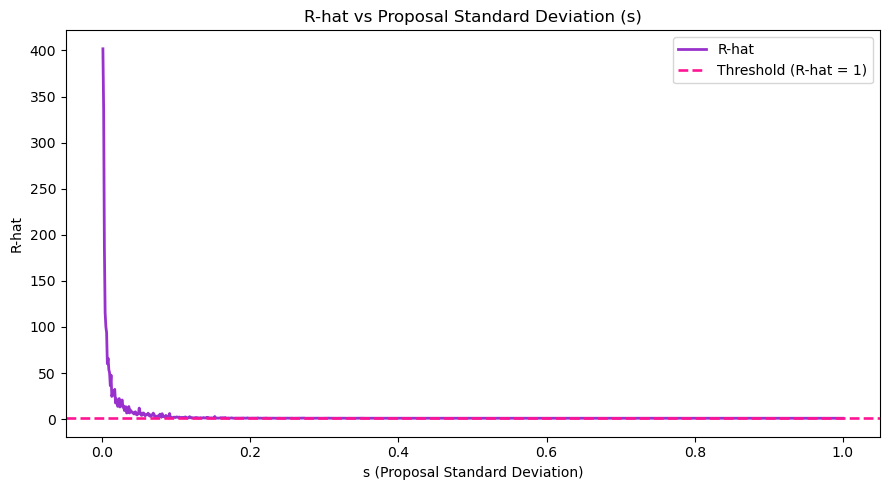

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(grid, R_hat_results, color='darkorchid', linewidth=2, label='R-hat')
ax.axhline(y=1, color='deeppink', linestyle='dashed', linewidth=1.9, label='Threshold (R-hat = 1)')

ax.set_title('R-hat vs Proposal Standard Deviation (s)')
ax.set_xlabel('s (Proposal Standard Deviation)')
ax.set_ylabel('R-hat')
ax.legend()
plt.tight_layout()
plt.show()